In [2]:
%load_ext autoreload

%autoreload 2

import pandas as pd
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

import torch.utils.data
from torch_geometric.data import Data
from torch.utils.tensorboard import SummaryWriter

from es import SimpleGA, CMAES, PEPG, OpenES

from torchvision import transforms
from entropy import sample_entropy

import classGridDataset
import useful_custom_functions
from grid import show_grid, load_grid, Graph_to_Grid
from models import FC_selu_first
from GVWAE import *

from geometric_ml import utils
from geometric_ml import manifolds
from geometric_ml import geodesics
import matplotlib.pyplot as plt


%load_ext autoreload

%autoreload 2

import pandas as pd
import numpy as np
from tqdm import tqdm
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
from shutil import copyfile
import matplotlib.pyplot as plt
%matplotlib inline

import torch.utils.data
from torch_geometric.data import Data
from torch.utils.tensorboard import SummaryWriter
import scipy.io as io
#from mtl import MTL
import io as file_io
#import matlab.engine
from data import *
from torchvision import transforms

from torch_geometric.data import DataLoader

import visual_tools
import classGridDataset
import useful_custom_functions
from grid import load_grid, show_grid, Graph_to_Grid, plot_cumulative_maps 
from curve import connecting_geodesic, linear_interpolation

from smoothness import smoothness_factor_simple, smoothness_factor_hard, plot_smoothness

from GVWAE import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
torch.manual_seed(187549026630100)

path_prefix = '../DATA/3_types_of_channels_with_stats/'
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
tensor_path = '../DATA/processed_dir/Channels_1500_tensor.pt'

####  GET FULL DATASET

In [4]:
dataset_list = get_dataset(path_prefix, tensor_path, device) 

E:\Research\PhD\PhD\Gleb\34) RGWAE_tnav_optim - !!!\CODE\classGridDataset.py:215: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  idx1 = torch.where(edge_start[::6] < (i_max * (edge_start[::6] // i_max + 1)) - 1)
E:\Research\PhD\PhD\Gleb\34) RGWAE_tnav_optim - !!!\CODE\classGridDataset.py:218: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').

you can find the tensor of properties in this file:  ../DATA/processed_dir/Channels_1500_tensor.pt


  0%|                                                                                         | 0/5000 [00:00<?, ?it/s]E:\Research\PhD\PhD\Gleb\34) RGWAE_tnav_optim - !!!\CODE\classGridDataset.py:215: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  idx1 = torch.where(edge_start[::6] < (i_max * (edge_start[::6] // i_max + 1)) - 1)
E:\Research\PhD\PhD\Gleb\34) RGWAE_tnav_optim - !!!\CODE\classGridDataset.py:218: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior

#### SAVE DATASET

In [ ]:
import pickle
with open('dataset.pickle', 'wb') as f:
    pickle.dump(dataset_list, f)

#### LOAD DATASET

In [5]:
import pickle 
with open('dataset.pickle', 'rb') as f:
    dataset_list = pickle.load(f)

##### TRANSFORM DATASET

In [6]:
dataset_list, transformer, max0 = transform_dataset(dataset_list) 

#### GET ITEM FROM MODEL

In [8]:
nv=1919 #Number of vertices in the graph
nz=30 # Latent code size
batch_size = 1
item = dataset_list[0]
trainer = TrainerRBF(batch_size=batch_size, nv=nv, nz=nz, model_loss='mmd', \
                     gamma=1, channels=2, num_centers=1000, edge_index=item.edge_index) 

trainer.model.load_state_dict(torch.load('R-GWAE_10_1919_30_mmd_1_2_1000_mu-500_si-500_Channels_1-3.pt'))
trainer.model.eval()


z = trainer.model.encode(dataset_list[1723], 1)
pred, _ = trainer.model.decode(z, trainer.edge_index, 1)

perm_list = transformer.inverse_transform(np.expand_dims(pred[0,:,1].detach().cpu().numpy(),axis=-1))[:,0]
poro_list = pred[0,:,0].detach().cpu().numpy()*max0.numpy()


RuntimeError: Error(s) in loading state_dict for RVAE:
	Missing key(s) in state_dict: "pr_means", "pr_t", "encoder.0.lin_l.weight", "encoder.0.lin_l.bias", "encoder.0.lin_r.weight", "encoder.2.lin_l.weight", "encoder.2.lin_l.bias", "encoder.2.lin_r.weight", "q_mu.0.weight", "q_mu.0.bias", "q_t.0.weight", "q_t.0.bias", "dummy_pmu.0.weight", "dummy_pmu.0.bias", "dummy_pmu.2.weight", "dummy_pmu.2.bias", "dummy_pmu.4.lin_l.weight", "dummy_pmu.4.lin_l.bias", "dummy_pmu.4.lin_r.weight", "dummy_pmu.6.lin_l.weight", "dummy_pmu.6.lin_l.bias", "dummy_pmu.6.lin_r.weight", "p_mu.0.weight", "p_mu.0.bias", "p_mu.2.weight", "p_mu.2.bias", "p_mu.4.lin_l.weight", "p_mu.4.lin_l.bias", "p_mu.4.lin_r.weight", "p_mu.6.lin_l.weight", "p_mu.6.lin_l.bias", "p_mu.6.lin_r.weight", "p_sigma.0.points", "p_sigma.1.weight". 
	Unexpected key(s) in state_dict: "decoder.decoder.0.weight", "decoder.decoder.0.bias", "decoder.decoder.2.weight", "decoder.decoder.2.bias", "decoder.p_mu.0.lin_l.weight", "decoder.p_mu.0.lin_

In [161]:
zs = []
for i in tqdm(range(len(dataset_list))):
    zs.append(trainer.model.encode(dataset_list[i], 1).detach().cpu().numpy())
zs = np.array(zs)
zs = zs[:,0,:,0]
zs_mean = np.mean(zs,axis=0)
zs_std = np.std(zs,axis=0)
zs_mean.shape, zs_std.shape

100%|█████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:14<00:00, 341.28it/s]


((30,), (30,))

In [259]:
manifold = manifolds.LocalDiagPCA(data=zs, sigma=np.std(zs), rho=np.expand_dims(np.mean(zs,axis=0),1))

In [265]:
solver_bvp = geodesics.SolverBVP(NMax=1000, tol=1e+3)

In [262]:
solver_fp = geodesics.SolverFP(D=30, N=100, tol=1e-1)

Kernel type has not been specified (default: Squared Exponential).



In [219]:
solver_graph = geodesics.SolverGraph(manifold, data=zs, kNN_num=5, tol=1e-2)
solver_comb = geodesics.SolverComb(solver_1=solver_bvp, solver_2=solver_graph)

  0%|                                                                                 | 4/5000 [00:00<05:23, 15.46it/s]

[Initialize Graph] [Processed point: 0/5000]


  2%|█▋                                                                             | 104/5000 [00:06<05:34, 14.65it/s]

[Initialize Graph] [Processed point: 100/5000]


  4%|███▏                                                                           | 202/5000 [00:12<04:53, 16.37it/s]

...

 96%|██████████████████████████████████████████████████████████████████████████▉   | 4801/5000 [13:10<01:09,  2.87it/s]

[Initialize Graph] [Processed point: 4800/5000]


 98%|████████████████████████████████████████████████████████████████████████████▍ | 4901/5000 [13:39<00:38,  2.55it/s]

[Initialize Graph] [Processed point: 4900/5000]


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [14:07<00:00,  5.90it/s]


In [220]:
c0 = zs[0]
c1 = zs[1723]

In [266]:
curve_bvp, logmap_bvp, curve_length_bvp, failed_bvp, solution_bvp \
                = geodesics.compute_geodesic(solver_bvp, manifold, c0, c1)

   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          2.15e+02       3.91e-14          30              0       
Solved in 1 iterations, number of nodes 30. 
Maximum relative residual: 2.15e+02 
Maximum boundary residual: 3.91e-14


R:\Work\Heriot Watt\Geogebra\RGVAE\30) RGWAE_and_first_dynamic_solver_2 - Copy\30) RGWAE_and_first_dynamic_solver_2 - Copy\CODE\geometric_ml\geodesics.py:133: IntegrationWarning:

The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.



In [267]:
curve_fp, logmap_fp, curve_length_fp, failed_fp, solution_fp \
                = geodesics.compute_geodesic(solver_fp, manifold, c0, c1)


In [224]:
curve_graph, logmap_graph, curve_length_graph, failed_graph, solution_graph \
                = geodesics.compute_geodesic(solver_graph, manifold, np.expand_dims(c0,axis=1), np.expand_dims(c1,axis=1))
geodesics.plot_curve(curve_graph, c='m', linewidth=2, label='graph')

In [268]:
curve_expmap_fp, failed_expmap_fp = geodesics.expmap(manifold, c0, logmap_fp)
geodesics.plot_curve(curve_expmap_fp, c='g', linewidth=2, label='fp')

In [271]:
N = 100
T = np.linspace(0, 1, N)
exp_fp = curve_expmap_fp(T)[0]
bvp = curve_bvp(T)[0]
fp = curve_fp(T)[0]

In [276]:
manifold.measure(bvp)

array([[8.93735144e-43],
       [2.60155674e-43],
       [8.09603399e-44],
       [2.78640728e-44],
       [1.09869640e-44],
       [5.13847915e-45],
       [2.93710409e-45],
       [2.10991468e-45],
       [1.94984250e-45],
       [2.35063693e-45],
       [3.73253269e-45],
       [7.84386341e-45],
       [2.16903778e-44],
       [7.79307412e-44],
       [3.57095067e-43],
       [2.03173432e-42],
       [1.39101149e-41],
       [1.10574176e-40],
       [9.80753435e-40],
       [9.35665098e-39],
       [9.27105338e-38],
       [9.20874789e-37],
       [8.91593008e-36],
       [8.24362347e-35],
       [7.14503778e-34],
       [5.72893049e-33],
       [4.22696176e-32],
       [2.86134076e-31],
       [1.77588822e-30],
       [1.01373226e-29],
       [5.34124696e-29],
       [2.60842561e-28],
       [1.18554335e-27],
       [5.01855452e-27],
       [1.97729399e-26],
       [7.23227771e-26],
       [2.43042756e-25],
       [7.38574952e-25],
       [1.98984104e-24],
       [4.60706289e-24],


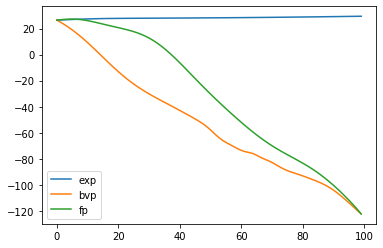

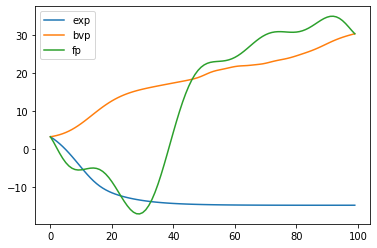

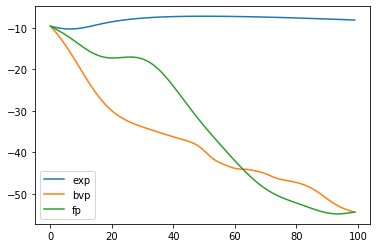

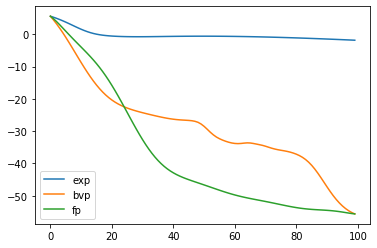

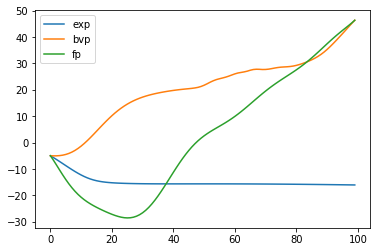

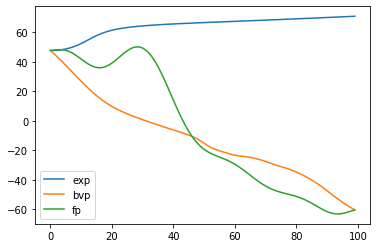

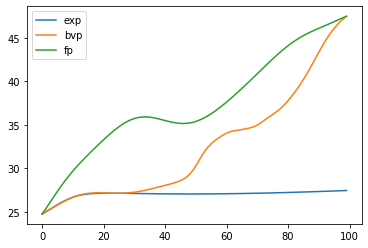

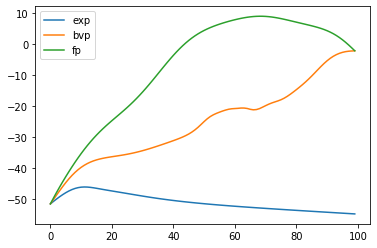

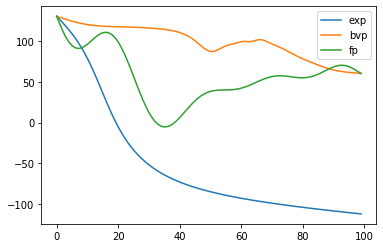

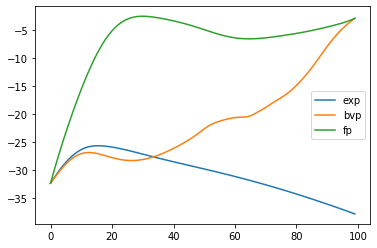

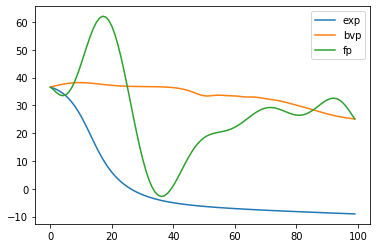

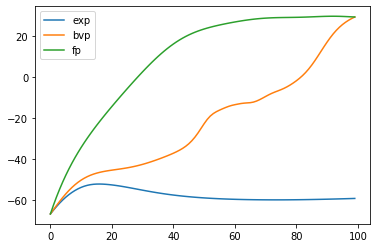

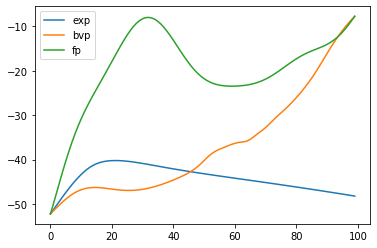

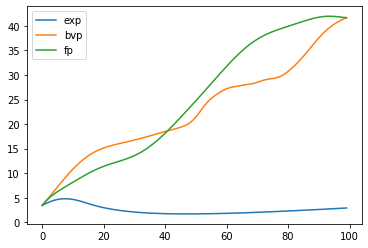

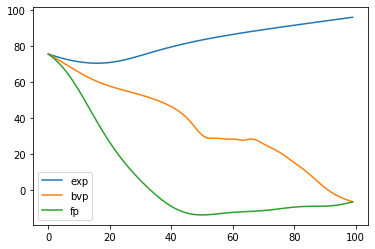

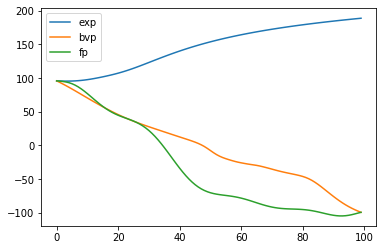

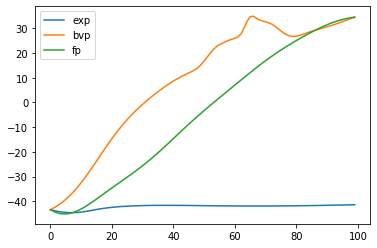

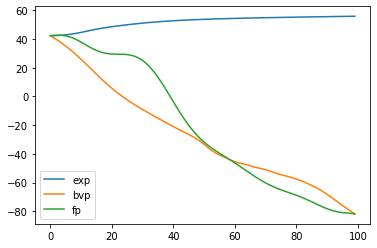

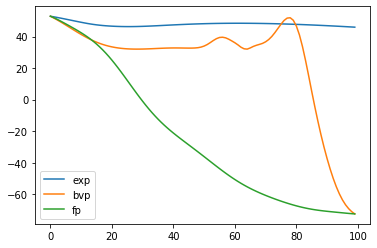

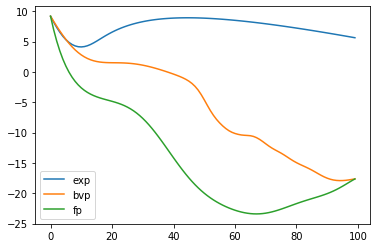

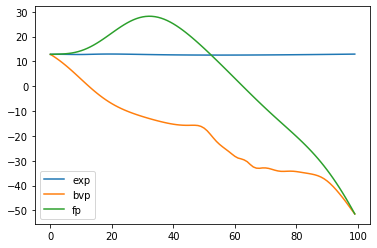

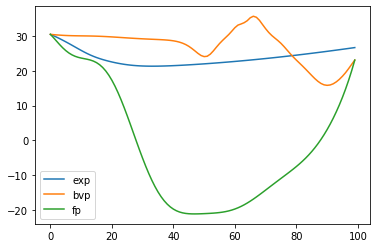

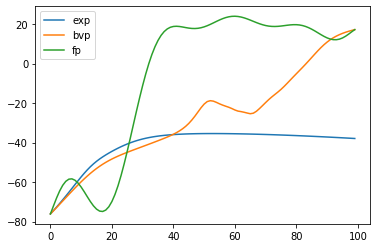

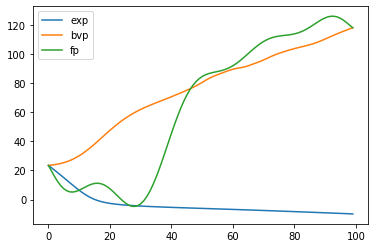

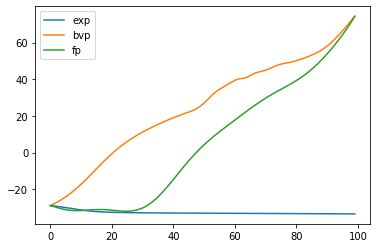

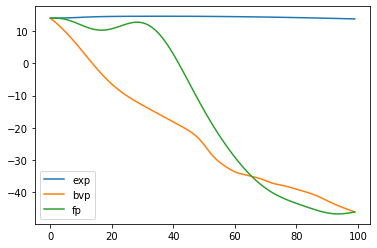

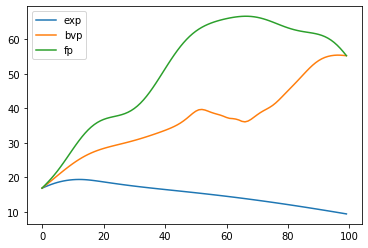

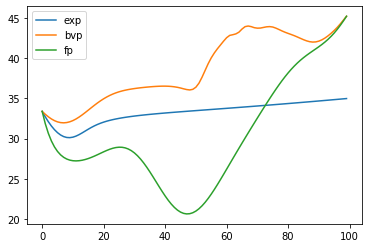

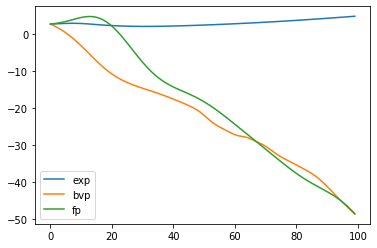

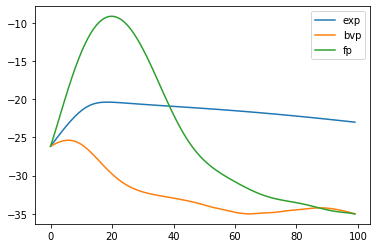

In [273]:
for k in range(30):
    plt.plot(exp_fp[k,:], label='exp')
    plt.plot(bvp[k,:], label='bvp')
    plt.plot(fp[k,:], label='fp')
    plt.legend()
    plt.show()

In [290]:
def save_it(curve, name):
    for NUM in range(len(curve[0])): 
        pred_geodesic, _ = trainer.model.decode(torch.reshape(torch.tensor(curve[:,NUM]).float(),(1,nz,1)).clone().cuda(), dataset_list[0].edge_index, 1)   
        pred_graph_geodesic = Data(x=pred_geodesic[0], label=dataset_list[0].label, edge_index=dataset_list[0].edge_index)
        if not os.path.isdir(path_prefix+f'Generated_grids\\{name}'):
            os.mkdir(path_prefix+f'Generated_grids\\{name}')
        Graph_to_Grid(path_prefix+'Facies.csv', pred_graph_geodesic, 0, 'poro', path_prefix+ f'Generated_grids\\{name}\\',str(NUM)+f'_Geodesic_{name}')
        
    for test in range(len(curve[0])):
        a = load_grid(path_prefix+f'Generated_grids\\{name}\\'+'poro'+str(test)+f'_Geodesic_{name}.GRDECL')
        z = np.ones((16,12,10))
        for i in range(16):
            for j in range(12):
                for k in range(10):
                    z[i][j][k] = a[i*16+j*12+k]
        plt.matshow(np.mean(z,axis=2))
        if not os.path.isdir(f'grid_interpolations_results\\geodesic\\{name}'):
            os.mkdir(f'grid_interpolations_results\\geodesic\\{name}')
        plt.savefig(f'grid_interpolations_results\\geodesic\\{name}\\grid'+str(test)+'.png')   


you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\bvp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\bvp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\bvp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\bvp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\bvp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\bvp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\bvp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\bvp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\bvp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\bvp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\bvp\
you can find your fil

c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:16: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).



you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\fp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\fp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\fp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\fp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\fp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\fp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\fp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\fp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\fp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\fp\
you can find your file here: ../DATA/3_types_of_channels_with_stats/Generated_grids\fp\
you can find your file here: ../

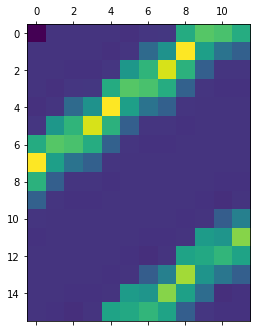

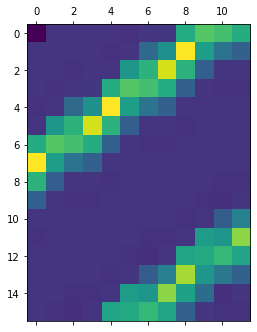

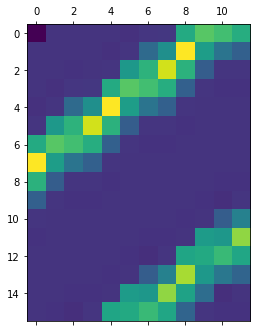

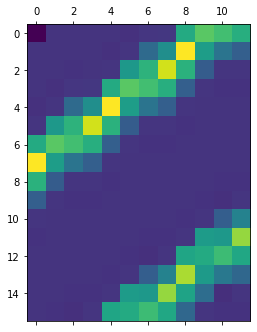

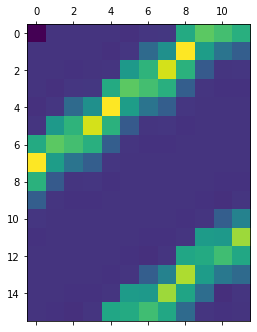

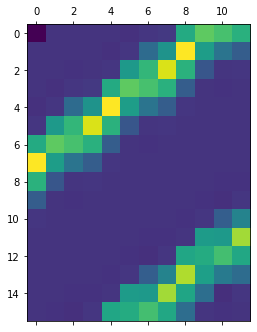

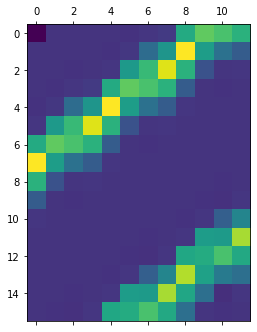

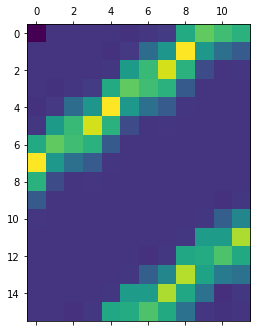

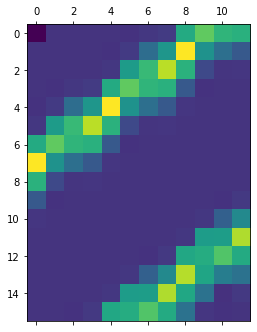

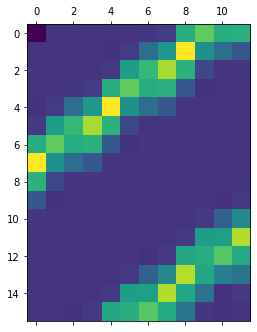

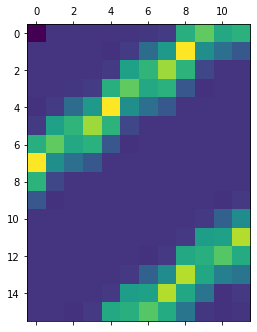

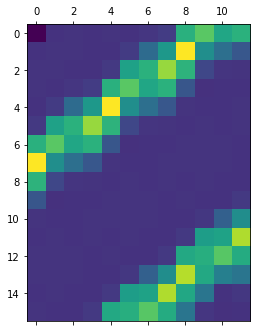

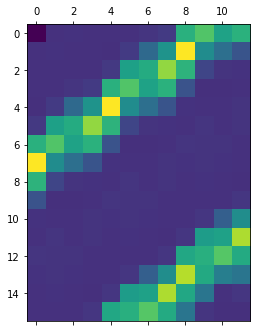

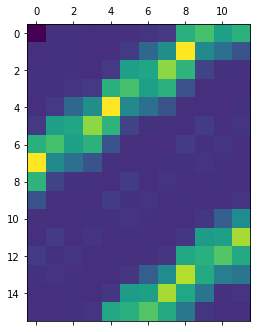

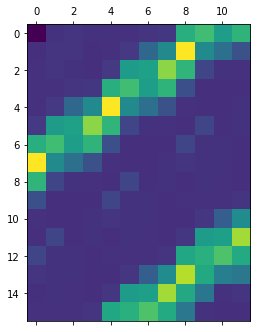

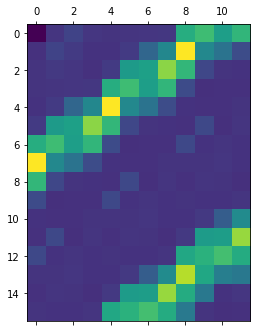

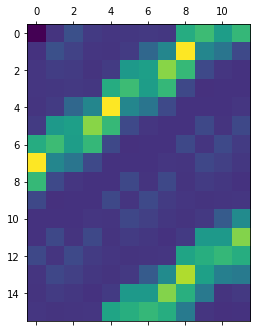

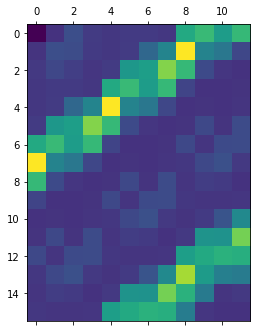

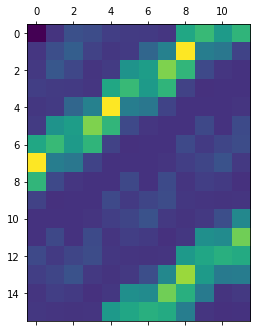

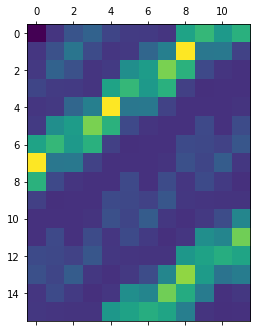

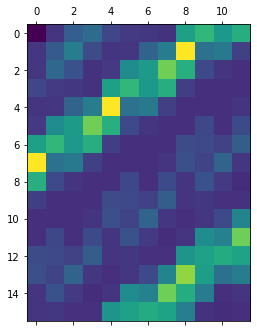

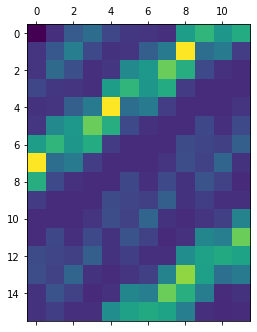

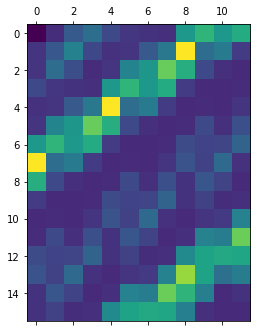

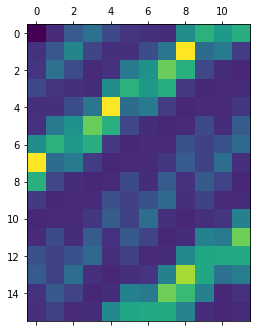

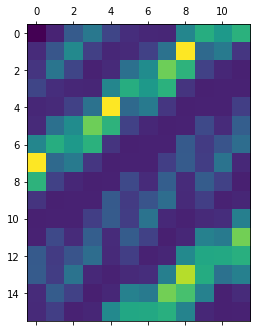

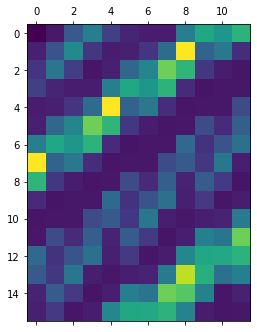

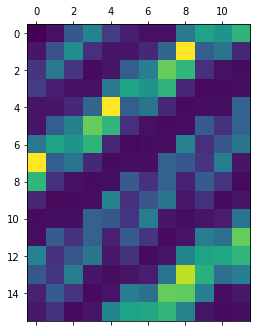

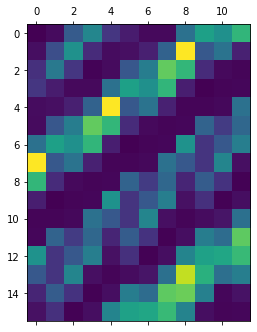

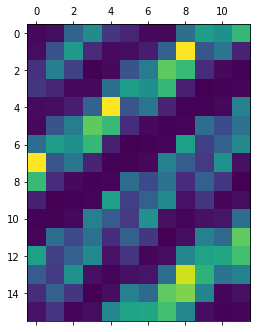

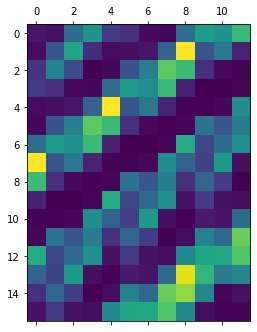

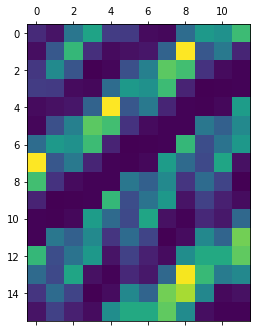

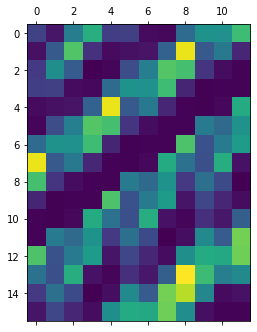

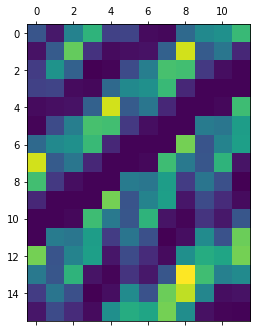

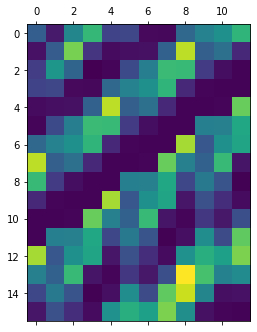

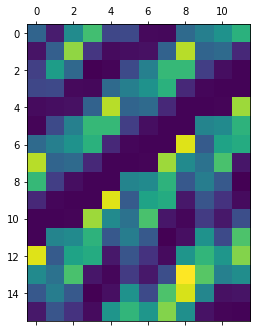

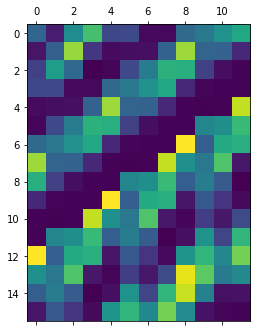

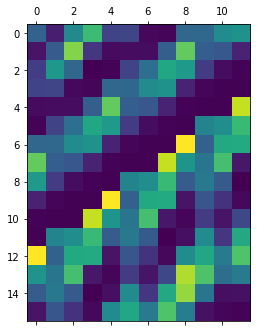

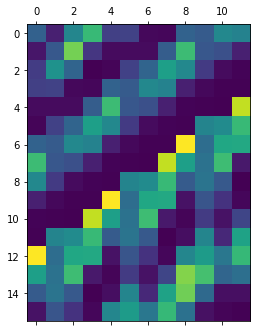

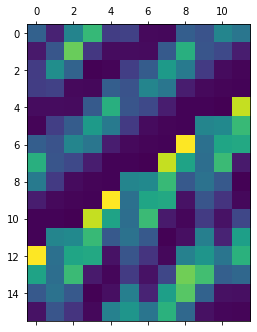

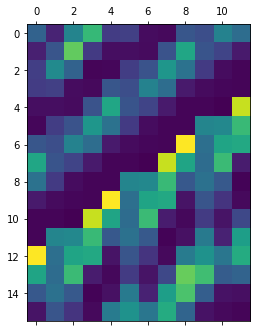

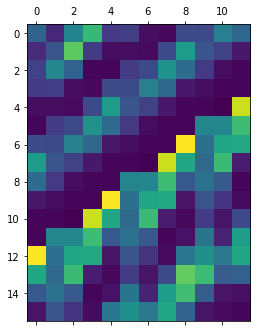

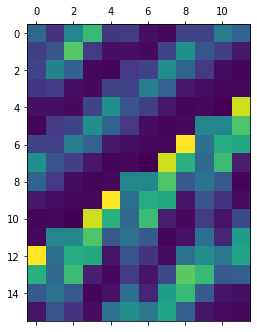

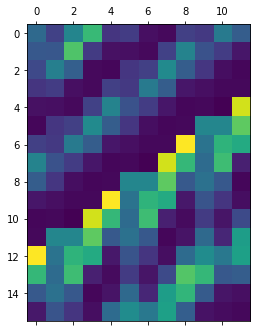

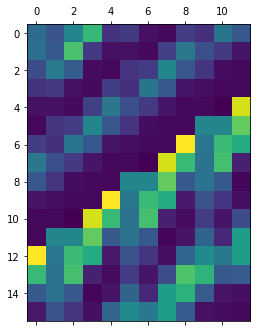

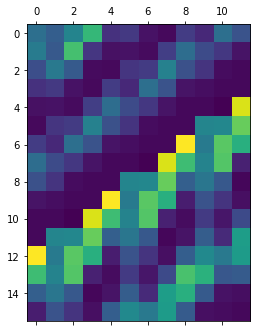

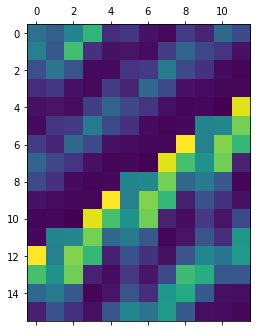

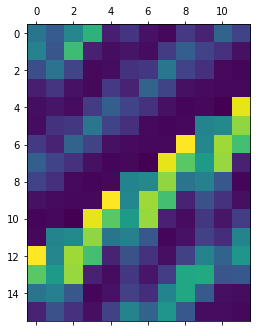

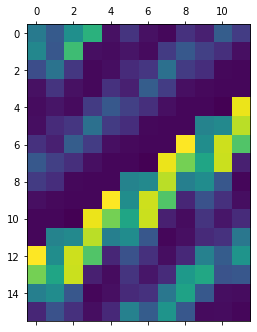

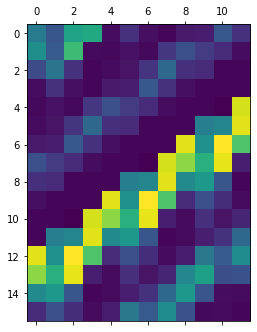

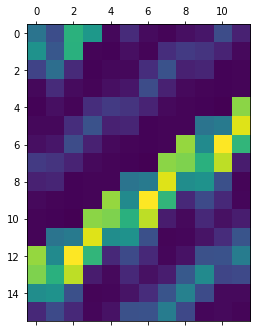

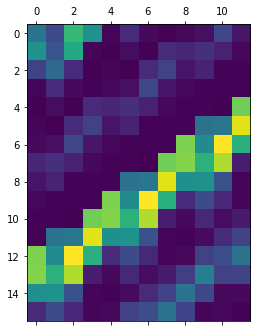

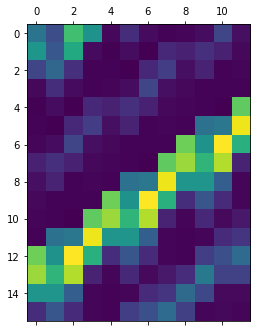

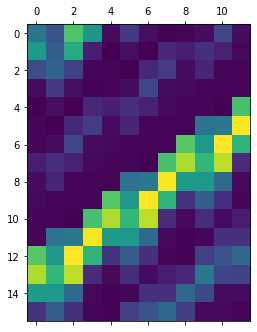

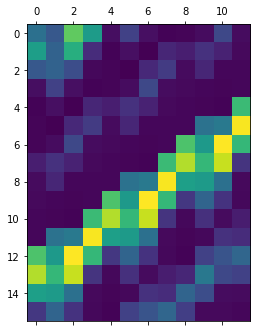

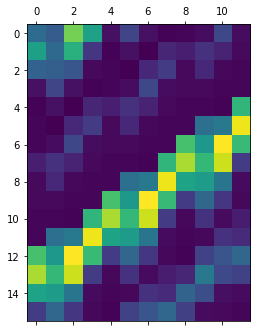

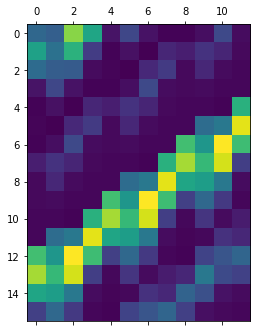

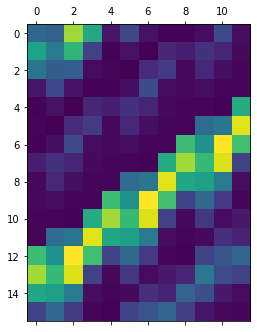

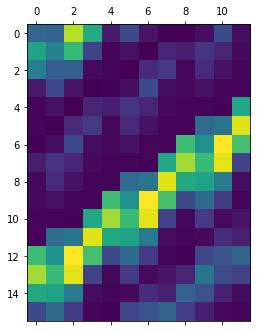

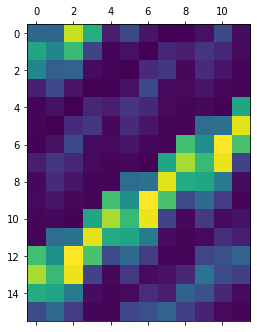

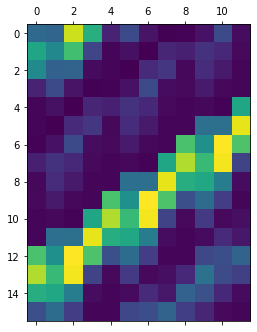

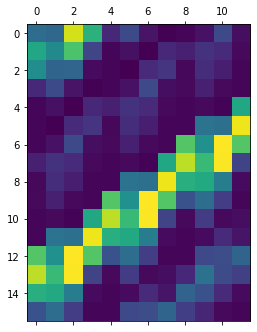

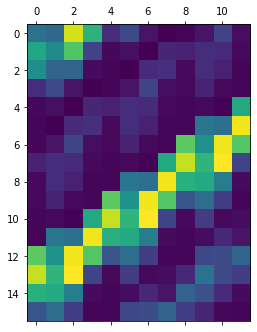

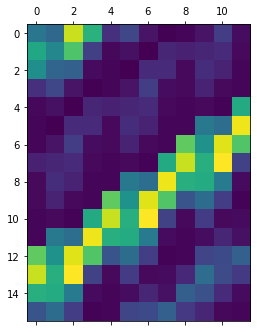

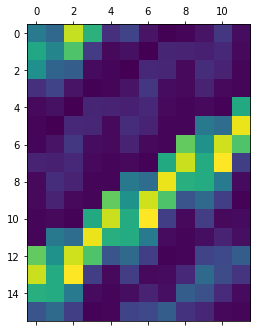

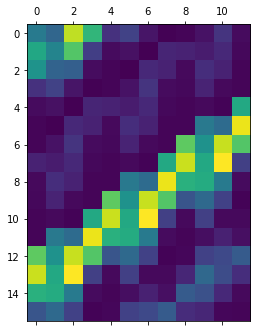

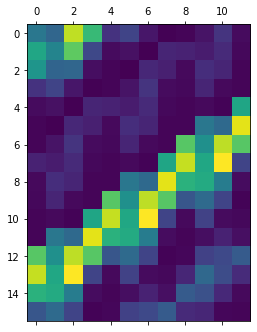

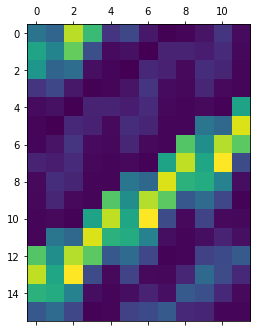

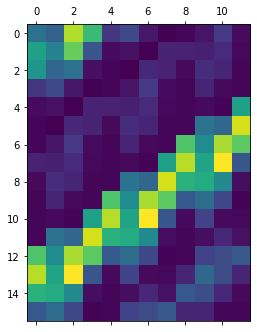

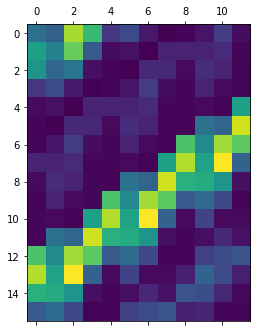

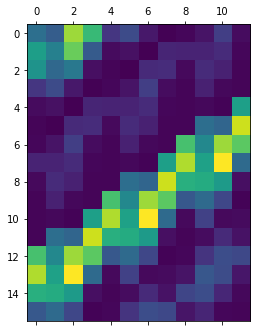

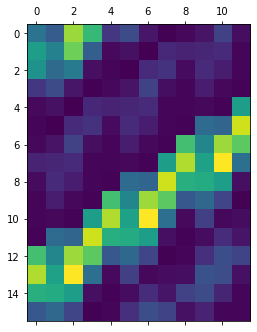

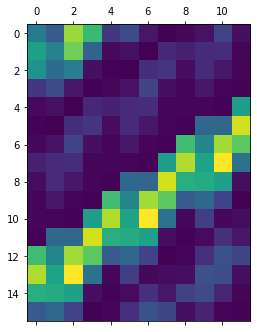

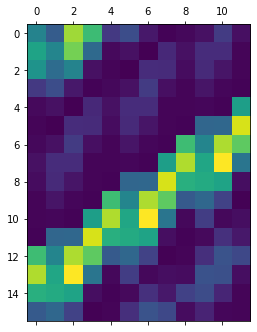

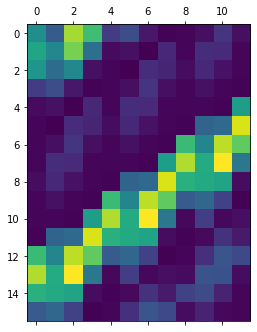

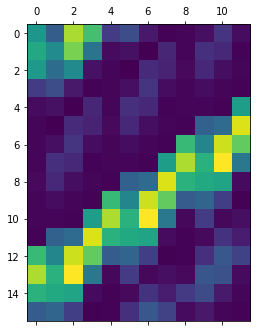

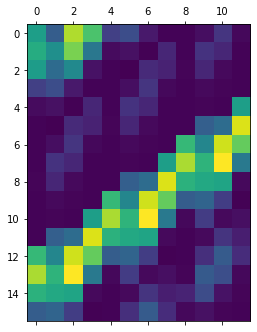

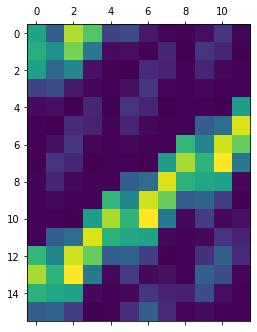

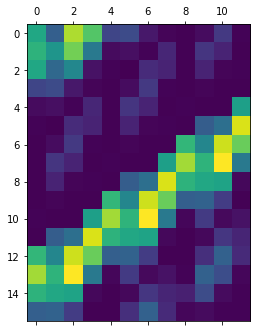

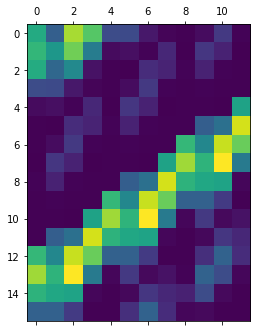

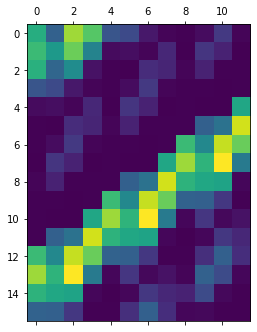

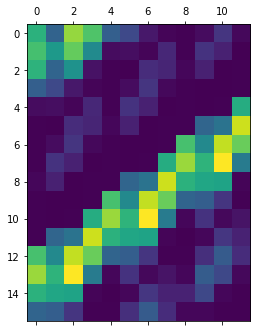

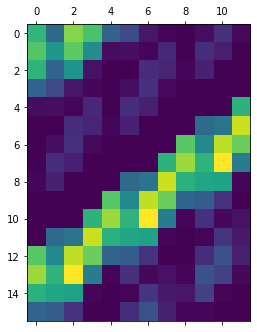

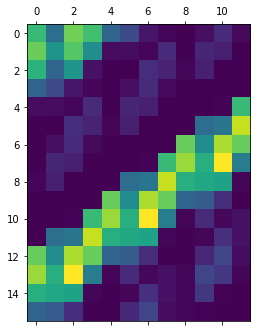

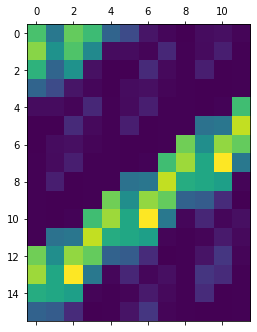

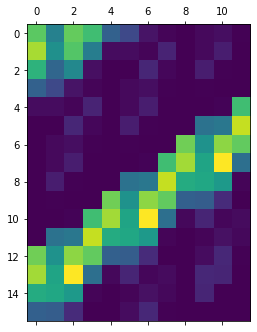

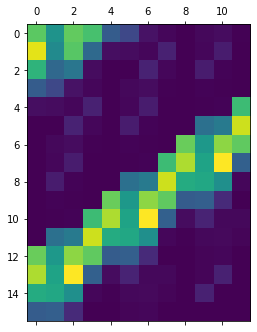

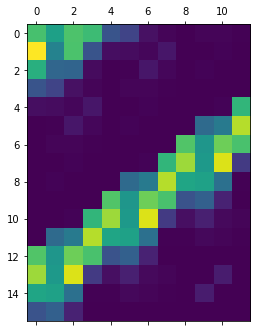

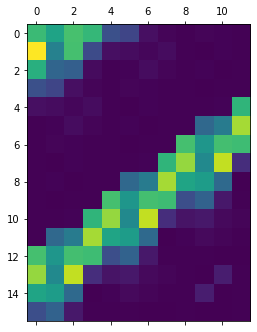

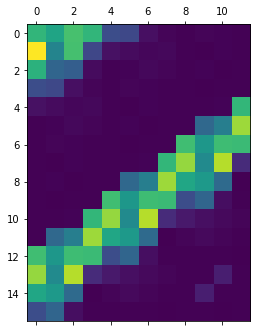

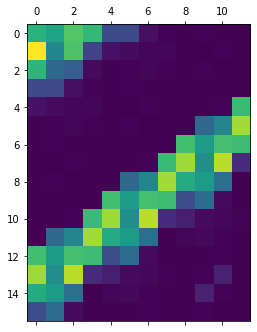

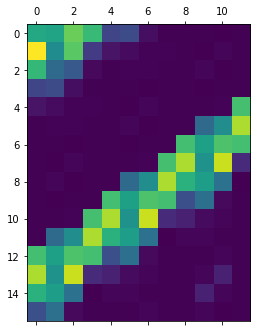

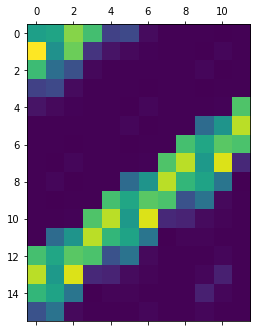

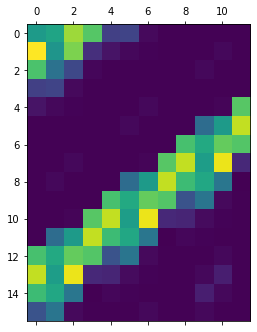

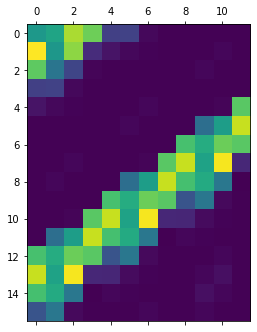

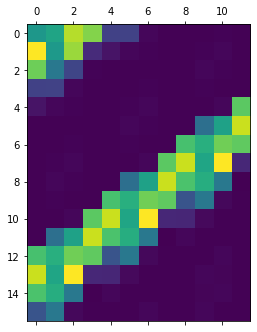

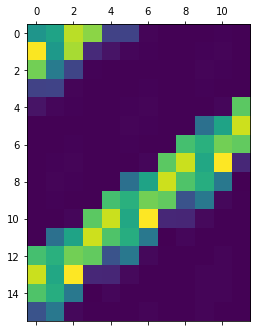

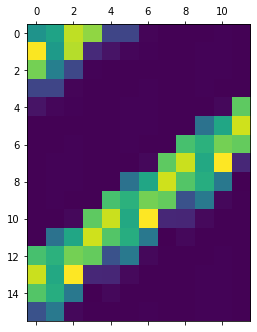

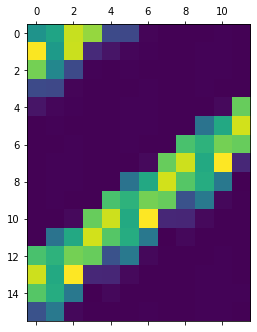

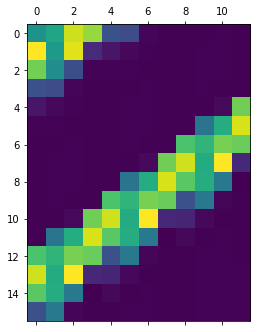

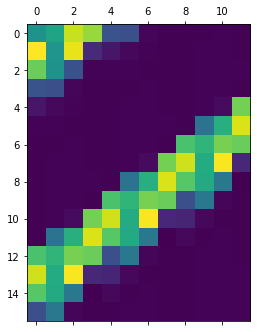

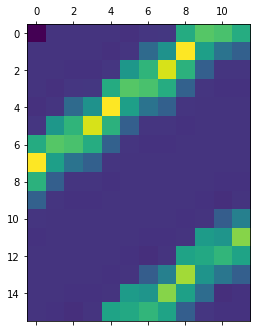

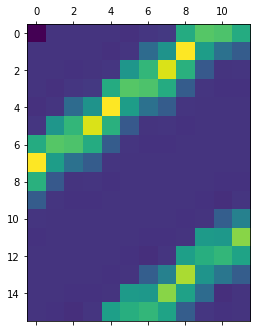

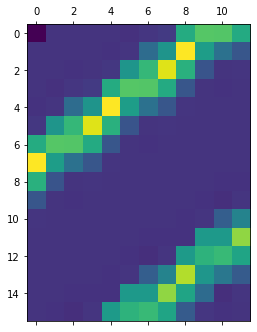

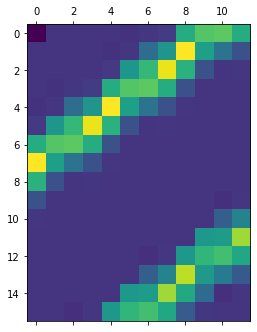

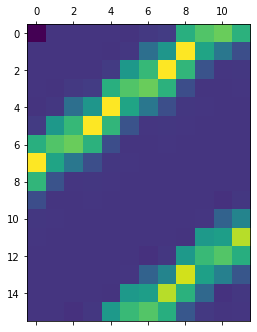

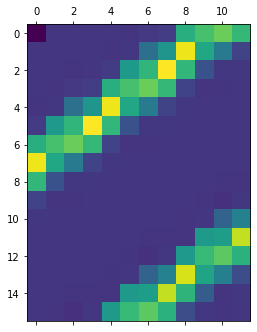

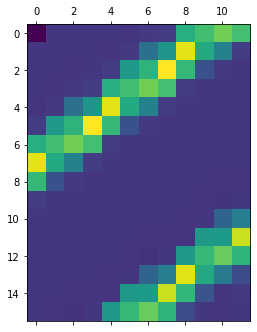

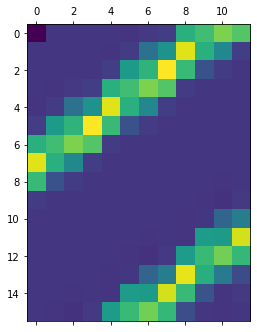

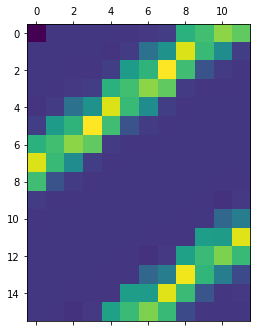

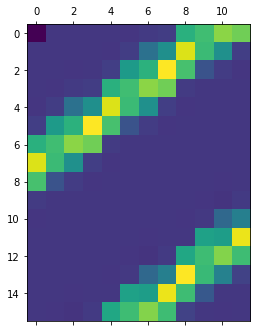

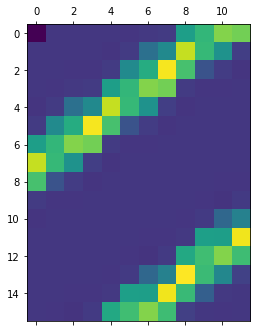

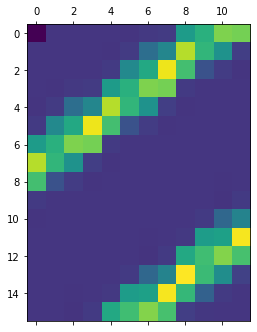

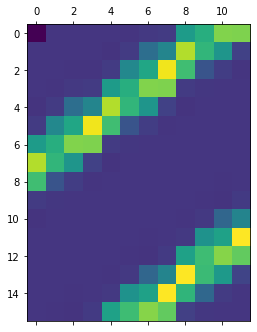

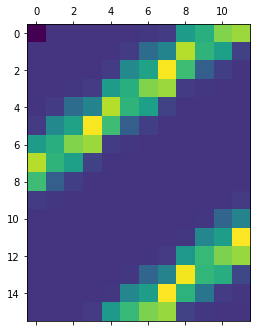

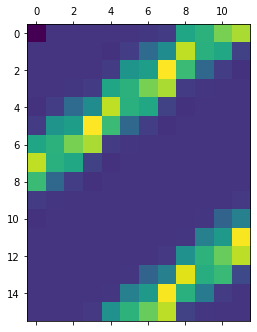

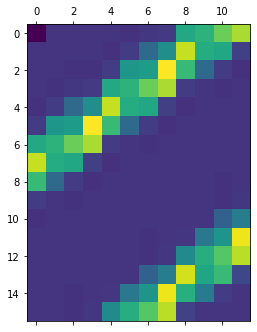

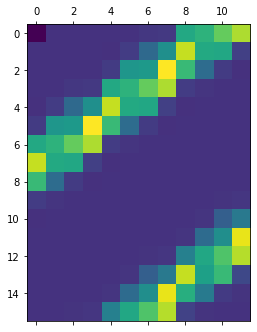

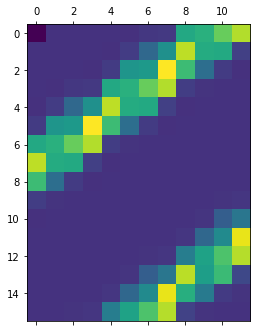

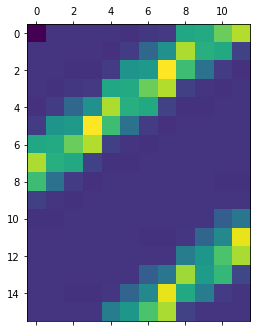

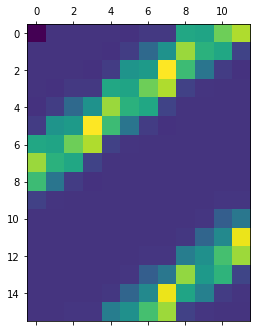

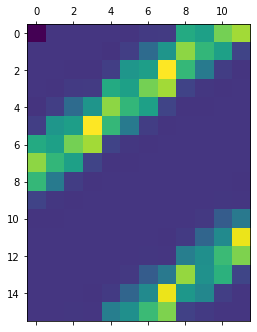

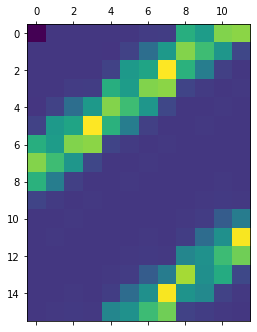

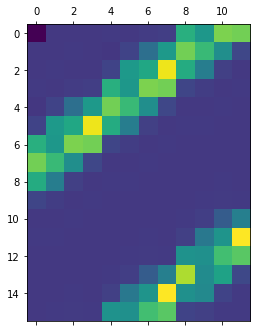

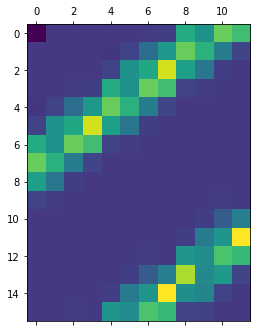

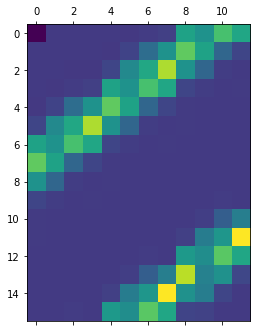

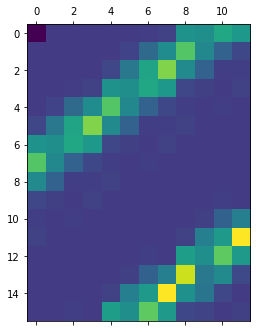

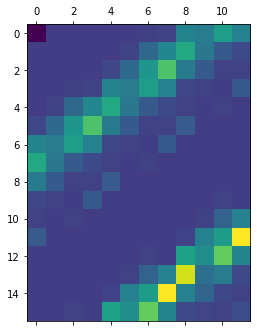

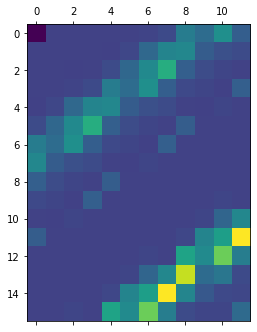

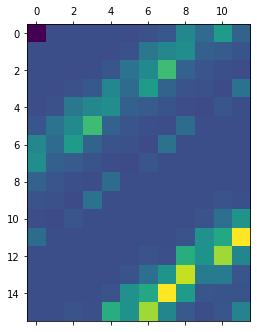

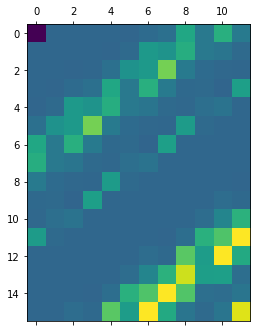

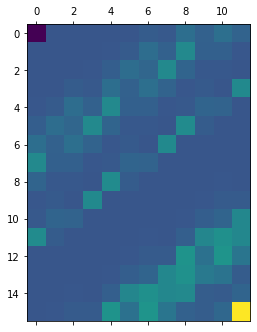

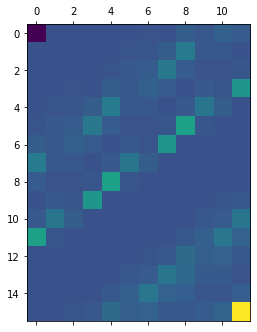

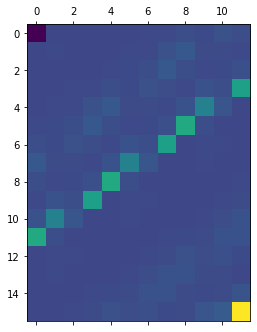

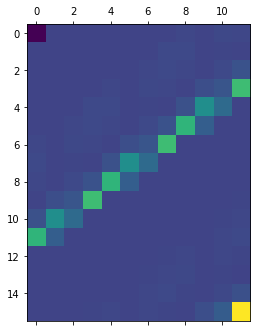

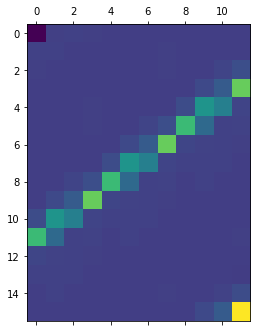

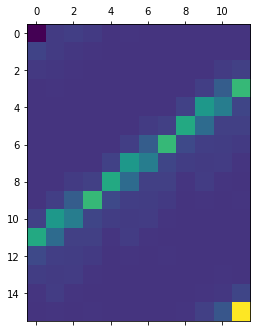

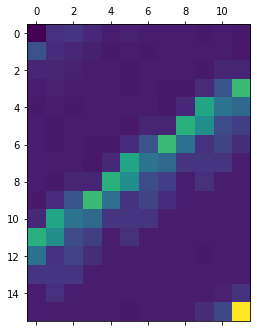

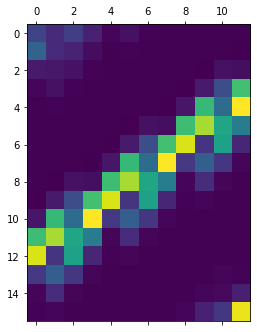

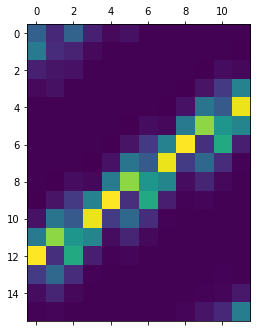

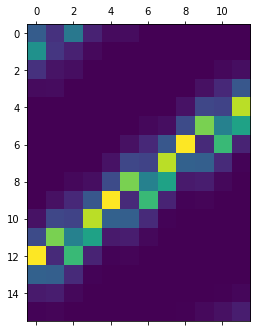

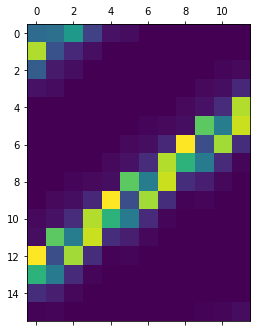

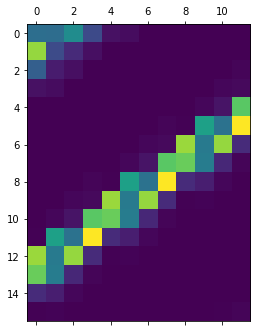

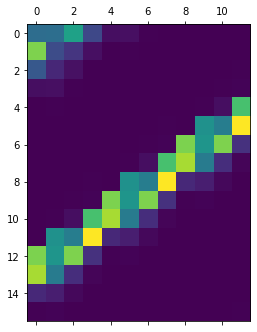

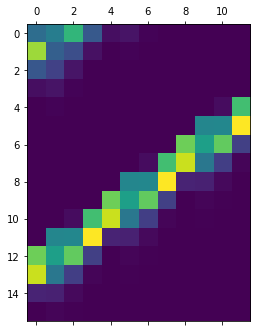

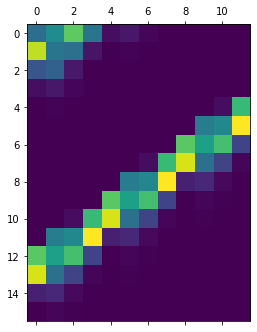

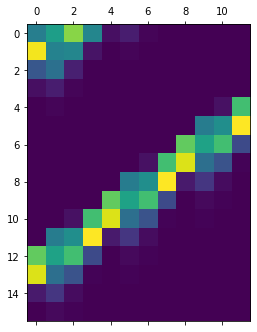

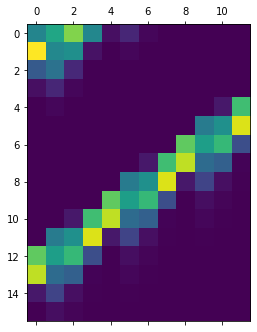

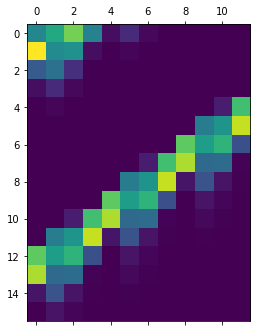

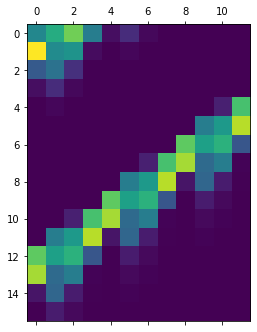

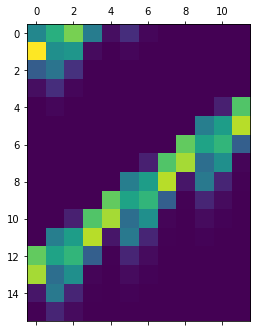

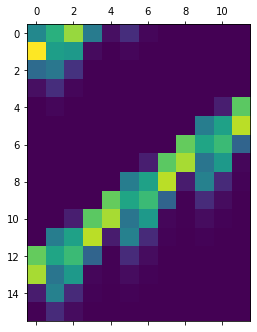

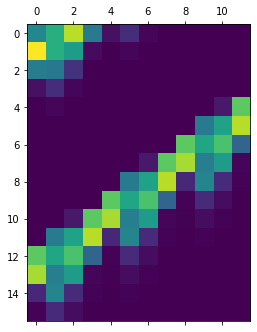

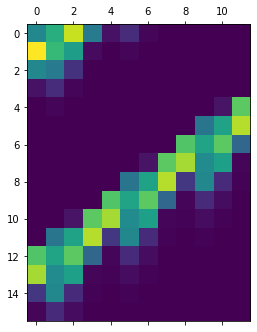

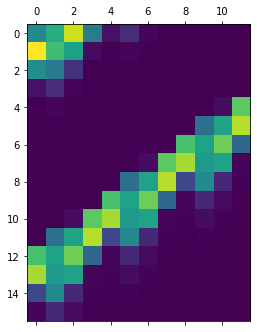

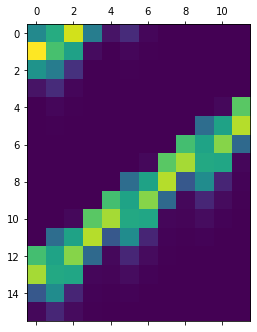

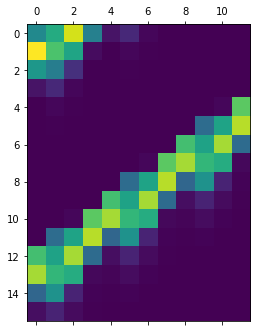

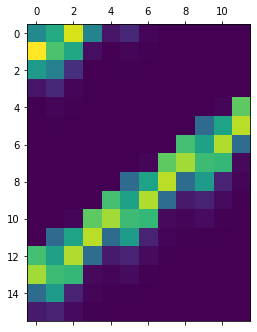

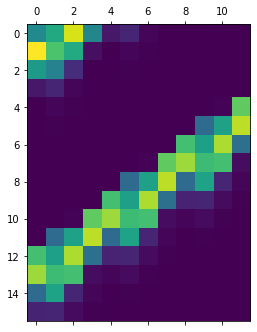

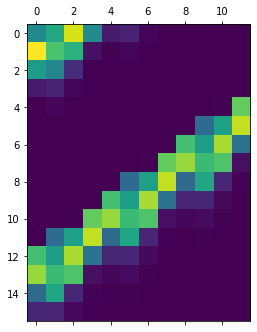

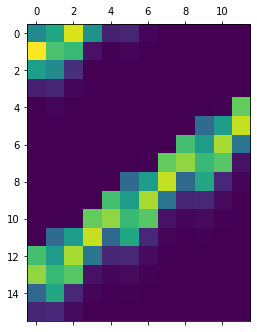

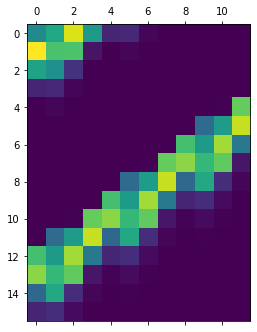

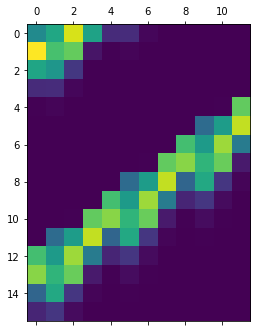

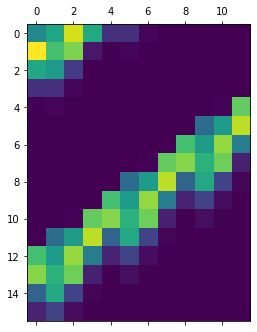

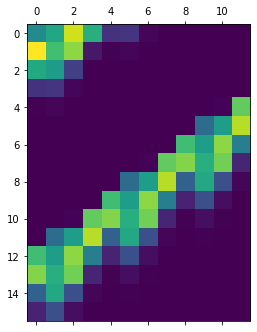

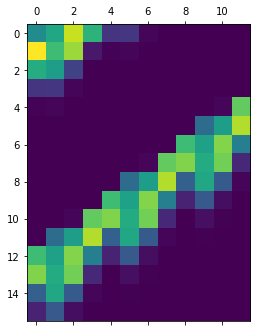

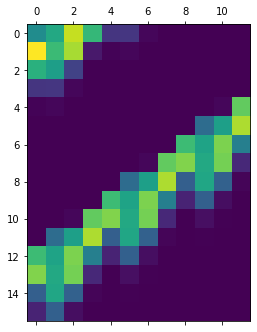

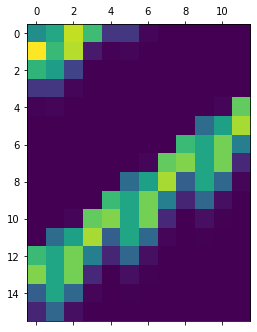

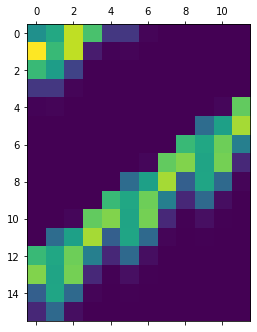

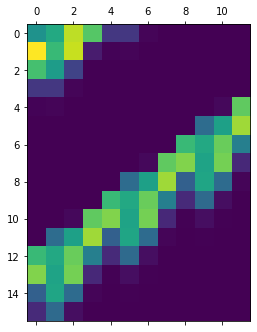

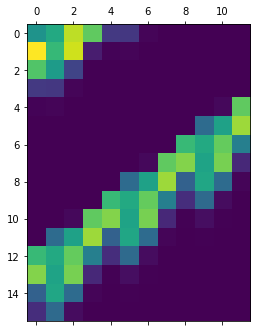

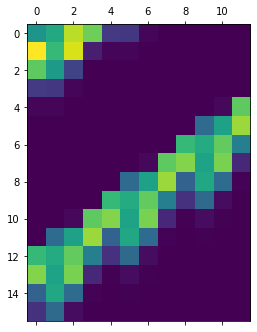

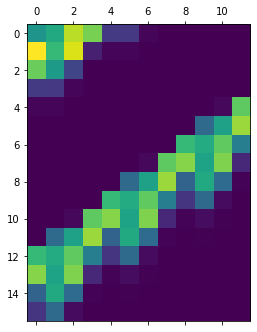

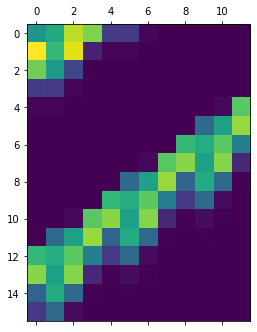

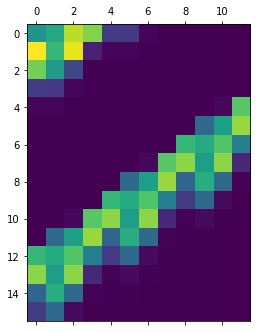

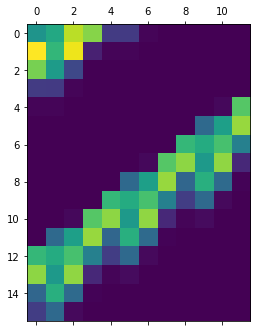

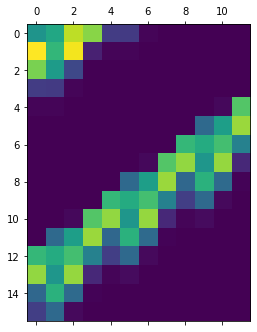

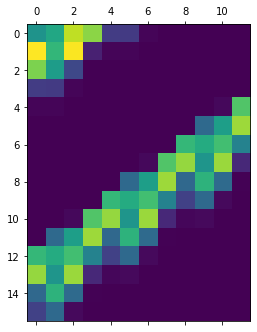

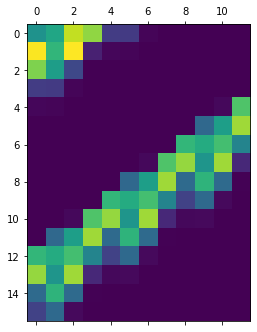

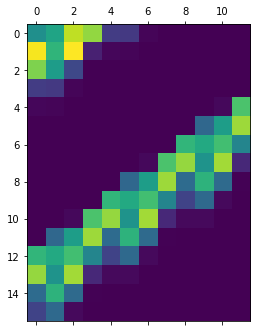

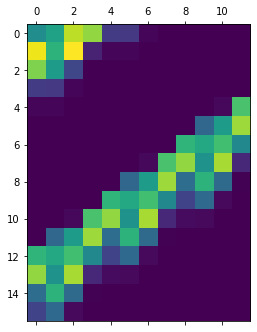

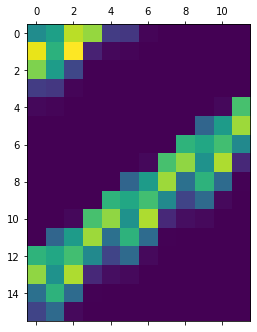

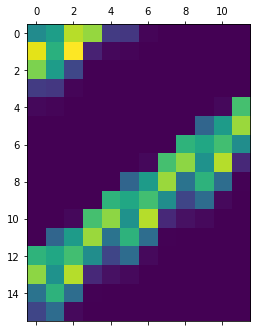

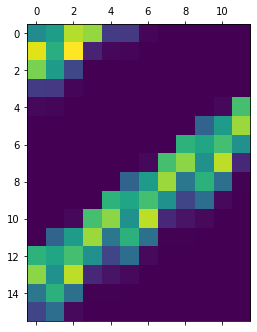

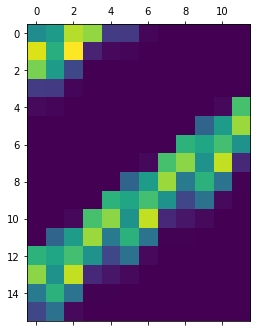

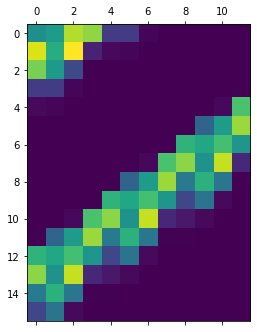

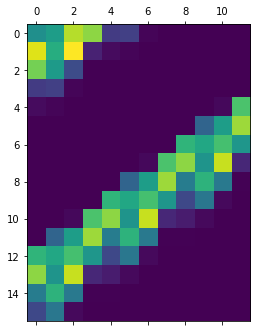

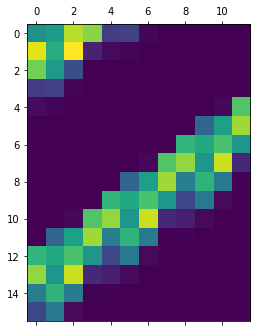

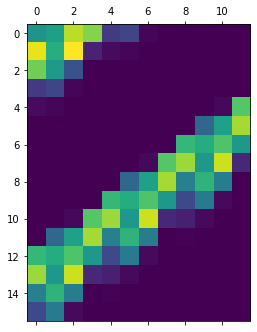

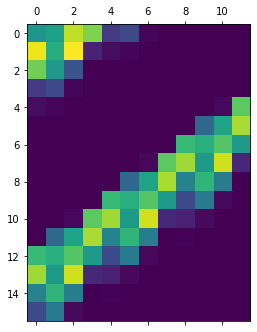

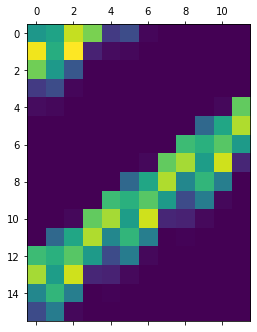

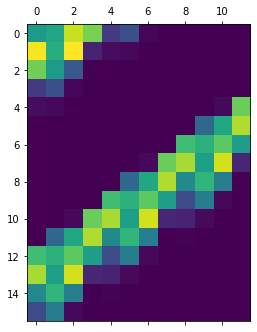

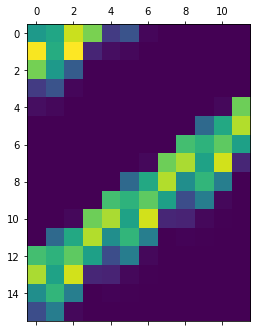

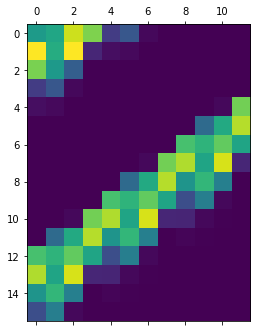

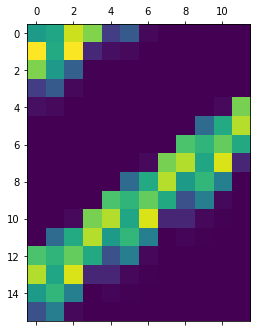

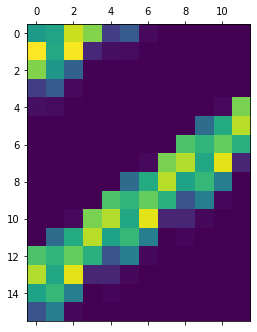

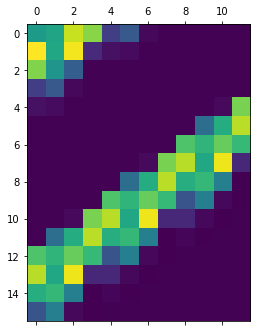

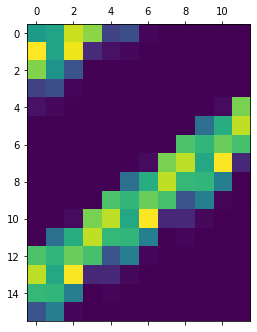

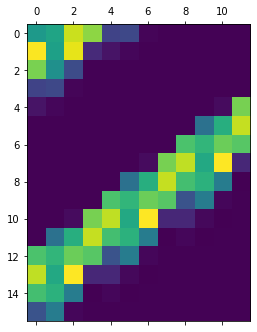

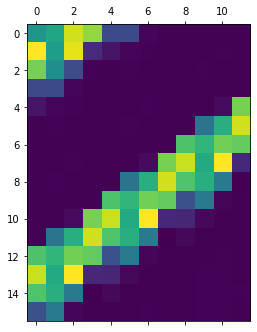

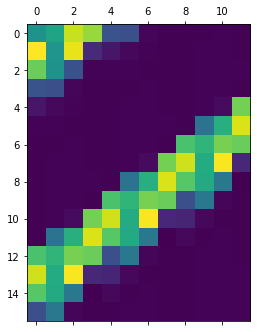

In [291]:
save_it(bvp, 'bvp')
save_it(fp, 'fp')

In [302]:
measures = []
for i in range(len(zs)):
    measures.append(manifold.measure(np.expand_dims(zs[i],1)))

In [303]:
measures

[array([[8.93736843e-43]]),
 array([[7.37653748e-33]]),
 array([[7.46140245e-41]]),
 array([[1.20937194e-37]]),
 array([[9.06694058e-40]]),
 array([[3.36568631e-38]]),
 array([[1.30779787e-45]]),
 array([[2.24496392e-38]]),
 array([[1.86698925e-43]]),
 array([[2.55438768e-21]]),
 array([[9.81044318e-41]]),
 array([[4.77110126e-33]]),
 array([[3.55732037e-45]]),
 array([[6.49809376e-39]]),
 array([[nan]]),
 array([[1.057853e-46]]),
 array([[1.64347302e-40]]),
 array([[7.15770929e-38]]),
 array([[2.49430144e-38]]),
 array([[8.24655898e-32]]),
 array([[7.10936185e-32]]),
 array([[2.83918919e-49]]),
 array([[3.61169664e-45]]),
 array([[1.61715316e-40]]),
 array([[6.1607914e-49]]),
 array([[1.30527401e-41]]),
 array([[1.55647721e-39]]),
 array([[9.55703814e-61]]),
 array([[2.99820903e-26]]),
 array([[2.11158828e-52]]),
 array([[1.7308884e-27]]),
 array([[5.45360999e-49]]),
 array([[1.05825415e-41]]),
 array([[1.85132705e-39]]),
 array([[1.55816308e-34]]),
 array([[1.38396371e-28]]),
 array(